# RAG-проект, КТ2: предобработка, чанкинг и метаданные

Беру сырой корпус из КТ1 (1650 постов из @egs_tg и @SteamByFree) и золотой набор. Сначала меряю baseline на грязных данных, потом по шагам чищу корпус, сравниваю чанкеры из Chonkie, отдельно разбираю семантический чанкинг, пробую parent/child на BGE-M3, метаданные и LLM-обработку чанков.

Как меряю. Ретривер BM25 (rank-bm25, токены это слова в нижнем регистре). Вопросы из val, только те, где ответ в корпусе есть, это 28 штук: негативным тут искать нечего. Релевантность по постам, то есть чанк считается правильным, если он из нужного поста. Hit@5 это нашёлся ли хоть один нужный пост в топ-5, Recall@k какую долю нужных постов нашли в топ-k, prec@5 доля правильных чанков в топ-5, MRR насколько высоко первый правильный. Все решения принимаю по val, test смотрю только в итоговой таблице.

Тяжёлое (эмбеддинги, семантический и нейро чанкинг, ответы LLM) кэширую в data/kt2_cache, при перезапуске заново это не считается.

In [1]:
%pip install -q "chonkie[all]" rank-bm25 sentence-transformers tiktoken datasketch scikit-learn pandas matplotlib "anthropic==0.125.0" beautifulsoup4

In [2]:
import warnings
warnings.filterwarnings('ignore')
import json, os, re, time, pickle, unicodedata
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['HF_HUB_VERBOSITY'] = 'error'
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tiktoken
import torch
import anthropic
from bs4 import BeautifulSoup
from rank_bm25 import BM25Okapi
from datasketch import MinHash, MinHashLSH
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from chonkie import TokenChunker, SentenceChunker, SemanticChunker, NeuralChunker, AutoEmbeddings
from transformers.utils import logging as hf_logging
hf_logging.disable_progress_bar()

%matplotlib inline
pd.set_option('display.width', 250)
pd.set_option('display.max_colwidth', 90)

try:
    from google.colab import userdata
    os.environ['ANTHROPIC_API_KEY'] = userdata.get('ANTHROPIC_API_KEY')
except ImportError:
    pass

DATA = Path('data') if Path('data').exists() else Path('../data')
CACHE = DATA / 'kt2_cache'
(CACHE / 'emb').mkdir(parents=True, exist_ok=True)
(CACHE / 'llm').mkdir(parents=True, exist_ok=True)
DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

corpus = pd.read_json(DATA / 'corpus_raw.jsonl', lines=True)
gold = json.load(open(DATA / 'gold_set.json', encoding='utf-8'))
val_q = [g for g in gold if g['split'] == 'val' and g['type'] != 'negative']
test_q = [g for g in gold if g['split'] == 'test' and g['type'] != 'negative']
print('постов:', len(corpus), '| val вопросов с ответом:', len(val_q), '| test:', len(test_q))

постов: 1650 | val вопросов с ответом: 28 | test: 12


In [3]:
enc = tiktoken.get_encoding('cl100k_base')
ntok = lambda s: len(enc.encode(s))

LETTER = re.compile('[A-Za-zА-Яа-яЁё]')
def is_noise(tok):
    return not LETTER.search(tok) or bool(re.search(r'[<>=]|https?:|www\.|t\.me', tok))
def noise_share(texts):
    toks = [t for s in texts for t in s.split()]
    return sum(map(is_noise, toks)) / max(1, len(toks))

WORD = re.compile(r'\w+')
def bm25_tok(t):
    return WORD.findall(t.lower()) or ['_']

class BM25Index:
    def __init__(self, chunks):
        t0 = time.time()
        self.chunks = chunks
        self.bm25 = BM25Okapi([bm25_tok(c['text']) for c in chunks])
        self.build_time = time.time() - t0
    def search(self, q, k=10, mask=None):
        s = self.bm25.get_scores(bm25_tok(q))
        if mask is not None:
            s = np.where(mask, s, -np.inf)
        idx = np.argsort(-s)[:k]
        return [self.chunks[i] for i in idx if np.isfinite(s[i])]

def evaluate(search, qs, dup_map=None, ks=(1, 3, 5, 10)):
    dup_map = dup_map or {}
    rows = []
    for g in qs:
        rel = {dup_map.get(d, d) for d in g['relevant_doc_ids']}
        docs = [c['doc_id'] for c in search(g['question'], max(ks))]
        r = {'qid': g['qid'], 'type': g['type']}
        for k in ks:
            top = docs[:k]
            found = rel & set(top)
            r[f'hit@{k}'] = float(bool(found))
            r[f'recall@{k}'] = len(found) / len(rel)
            r[f'prec@{k}'] = sum(d in rel for d in top) / k
        r['mrr'] = next((1 / (i + 1) for i, d in enumerate(docs) if d in rel), 0.0)
        rows.append(r)
    return pd.DataFrame(rows)

METRICS = ['hit@5', 'recall@5', 'recall@10', 'prec@5', 'mrr']
def summary(df):
    return df[METRICS].mean().round(3)

def chunk_docs(docs, chunker):
    out = []
    for d in docs:
        if not d['text'].strip():
            continue
        parts = chunker.chunk(d['text'])
        for i, c in enumerate(parts):
            out.append({'doc_id': d['doc_id'], 'source': d['source'], 'date': d['date'], 'pos': i, 'n_parts': len(parts),
                        'text': c.text, 'tokens': c.token_count})
    return out

def chunk_stats(chunks):
    t = np.array([c['tokens'] for c in chunks])
    return {'n_chunks': len(t), 'mean': round(t.mean(), 1), 'median': float(np.median(t)), 'std': round(t.std(), 1),
            'lt50_%': round(100 * (t < 50).mean(), 1), 'gt500_%': round(100 * (t > 500).mean(), 1)}

FINAL, SEARCHERS = [], {}
def log_final(name, search, chunks, index_time, dup_map, **parts):
    s = summary(evaluate(search, val_q, dup_map))
    st = chunk_stats(chunks)
    FINAL.append({'config': name, **parts, 'n_chunks': st['n_chunks'], 'mean_tokens': st['mean'],
                  'index_time_s': round(index_time, 2), **{f'val_{m}': s[m] for m in METRICS}})
    SEARCHERS[name] = (search, dup_map)
    return s

## 0. Baseline на сырых данных

Сырой HTML постов как есть, TokenChunker на 512 токенов, BM25. От этой точки дальше всё и считаю.

In [4]:
docs_raw = [{'doc_id': r.doc_id, 'source': r.source, 'date': str(r.date), 'text': r.raw_html} for r in corpus.itertuples()]
token512 = TokenChunker(tokenizer='cl100k_base', chunk_size=512)
chunks_raw = chunk_docs(docs_raw, token512)
bm25_raw = BM25Index(chunks_raw)
base_eval = evaluate(bm25_raw.search, val_q)
print('чанков:', len(chunks_raw))
summary(base_eval)

чанков: 2244


hit@5        0.714
recall@5     0.661
recall@10    0.737
prec@5       0.207
mrr          0.696
dtype: float64

## 1. Предобработка

Шаги делаю по очереди и после каждого меряю корпус и поиск, чанкер везде тот же token 512:
- 1a: убираю HTML через BeautifulSoup;
- 1b: убираю навигацию и шаблоны, это подписи каналов в конце постов (Epic Games Store, Халявный Steam с 🎮), служебные посты (pinned, смена аватарки) и строки Реклама erid;
- 2: нормализация: NFKC, неразрывные и нулевые пробелы, лишние пробелы и переносы;
- 3: эмодзи, два варианта. 3a удаляю все. 3b сначала перевожу keycap цифры в обычные (8️⃣5️⃣ в 85), потом удаляю остальные эмодзи;
- 4: дедупликация, точные дубли плюс MinHash с порогом 0.7, как в КТ1. Если удалённый пост был в золотом наборе, его ссылку перекидываю на оставшийся дубль.

Шум считаю как долю токенов без букв плюс куски разметки и ссылки.

In [5]:
def strip_html(h):
    return BeautifulSoup(h, 'html.parser').get_text('\n')

BOILER_LINES = {'Epic Games Store', 'Халявный Steam', '🎮', 'Халявный Steam 🎮'}
SERVICE = re.compile(r'pinned (a photo|Deleted message|a video|a message)|Channel photo updated|Channel name was changed', re.I)
def strip_boiler(t):
    if SERVICE.search(t):
        return ''
    lines = [l.strip() for l in t.split('\n')]
    while lines and (not lines[-1] or lines[-1] in BOILER_LINES or re.fullmatch(r'Халявный Steam\s*🎮?', lines[-1])):
        lines.pop()
    lines = [l for l in lines if not re.match(r'Реклама\.?\s*erid', l)]
    return '\n'.join(lines)

def normalize(t):
    t = unicodedata.normalize('NFKC', t)
    t = re.sub('[\u00a0\u2009\u202f]', ' ', t)
    t = re.sub('[\u200b\u200c\u2060]', '', t)
    t = re.sub(r'[ \t]+', ' ', t)
    t = re.sub(r' *\n *', '\n', t)
    t = re.sub(r'\n{3,}', '\n\n', t)
    return t.strip()

EMOJI = re.compile('[\U0001F000-\U0001FAFF\u2600-\u27BF\u2B00-\u2BFF\u25A0-\u25FF\u2190-\u21FF\uFE0F\u200D\u20E3]')
KEYCAPS = re.compile(r'(?:\d\uFE0F?\u20E3\s*)+')
def emoji_remove_all(t):
    return normalize(EMOJI.sub(' ', t))
def emoji_keycap_digits(t):
    t = KEYCAPS.sub(lambda m: re.sub(r'\D', '', m.group(0)) + ' ', t)
    return normalize(EMOJI.sub(' ', t))

def dedup(docs, thr=0.7):
    def norm(t):
        return re.sub(r'\s+', ' ', re.sub(r'[^\w\s]', ' ', re.sub(r'https?://\S+', ' ', t.lower()))).strip()
    keep, dup_map, seen = [], {}, {}
    for d in docs:
        n = norm(d['text'])
        if not n:
            continue
        if n in seen:
            dup_map[d['doc_id']] = seen[n]
            continue
        seen[n] = d['doc_id']
        keep.append(d)
    lsh, final = MinHashLSH(threshold=thr, num_perm=128), []
    for d in keep:
        w = norm(d['text']).split()
        if len(w) < 5:
            final.append(d)
            continue
        m = MinHash(num_perm=128, seed=1)
        for i in range(max(1, len(w) - 4)):
            m.update(' '.join(w[i:i + 5]).encode())
        hits = lsh.query(m)
        if hits:
            dup_map[d['doc_id']] = hits[0]
            continue
        lsh.insert(d['doc_id'], m)
        final.append(d)
    return final, dup_map

print('пример keycap:', repr(emoji_keycap_digits('получила скидку 8️⃣ 5️⃣ на неделю')))

пример keycap: 'получила скидку 85 на неделю'


In [6]:
steps = {'0 сырой HTML': docs_raw}
steps['1a удаление HTML'] = [dict(d, text=strip_html(d['text'])) for d in steps['0 сырой HTML']]
steps['1b подписи и служебные посты'] = [dict(d, text=strip_boiler(d['text'])) for d in steps['1a удаление HTML']]
steps['2 нормализация'] = [dict(d, text=normalize(d['text'])) for d in steps['1b подписи и служебные посты']]
steps['3a эмодзи: удалить все'] = [dict(d, text=emoji_remove_all(d['text'])) for d in steps['2 нормализация']]
steps['3b эмодзи: keycap в цифры, остальные удалить'] = [dict(d, text=emoji_keycap_digits(d['text'])) for d in steps['2 нормализация']]
docs_clean, dup_map = dedup([d for d in steps['3b эмодзи: keycap в цифры, остальные удалить'] if d['text'].strip()])
steps['4 дедупликация'] = docs_clean

rows = []
for name, docs in steps.items():
    nonempty = [d for d in docs if d['text'].strip()]
    ch = chunk_docs(nonempty, token512)
    dm = dup_map if name.startswith('4') else None
    s = summary(evaluate(BM25Index(ch).search, val_q, dm))
    rows.append({'шаг': name, 'постов': len(nonempty), 'токенов': sum(ntok(d['text']) for d in nonempty),
                 'шум_%': round(100 * noise_share([d['text'] for d in nonempty]), 1), 'чанков': len(ch), **s})
clean_table = pd.DataFrame(rows)
n_before = len([d for d in steps['3b эмодзи: keycap в цифры, остальные удалить'] if d['text'].strip()])
print(f'дедупликация убрала {n_before - len(docs_clean)} постов ({100 * (n_before - len(docs_clean)) / n_before:.1f}%), из них точных и почти-дублей: {len(dup_map)}')
clean_table

дедупликация убрала 5 постов (0.3%), из них точных и почти-дублей: 5


,шаг,постов,токенов,шум_%,чанков,hit@5,recall@5,recall@10,prec@5,mrr
0,0 сырой HTML,1636,695374,44.9,2244,0.714,0.661,0.737,0.207,0.696
1,1a удаление HTML,1636,292959,20.1,1733,0.750,0.683,0.727,0.214,0.727
2,1b подписи и служебные посты,1627,280068,20.5,1723,0.714,0.679,0.722,0.207,0.719
3,2 нормализация,1627,279951,20.4,1722,0.714,0.679,0.722,0.207,0.719
4,3a эмодзи: удалить все,1627,264390,17.5,1721,0.714,0.679,0.722,0.207,0.719
5,"3b эмодзи: keycap в цифры, остальные удалить",1627,263555,17.2,1721,0.714,0.679,0.722,0.207,0.719
6,4 дедупликация,1622,263040,17.2,1716,0.714,0.679,0.718,0.207,0.719


Что получилось:
- больше всего дало удаление HTML: корпус ужался с 695 до 293 тыс токенов, шум с 45% до 20%, Hit@5 вырос с 0.714 до 0.750, Recall@5 с 0.661 до 0.683. На сыром HTML BM25 цеплялся за куски разметки типо href и tg-emoji;
- удаление подписей и служебки по цифрам вроде как ухудшило, Hit@5 обратно 0.714. Проверил ниже: это один вопрос q37 (абстрактный и мутный), у него нужный пост стоял ровно на 5 месте и уехал за 10. Подпись меняет длину всех постов, а от длины в BM25 зависит нормировка, так что это шум, а не эффект шага. Шаг оставил, подпись никакой инфы не несёт;
- нормализация и эмодзи на BM25 не влияют вообще, и это понятно: токенизатор берёт только слова и цифры, пробелы и эмодзи он и так пропускает. Шум при этом упал с 20.4 до 17.2%;
- 3a и 3b по средним цифрам одинаковые, но на конкретных запросах разница есть, это ниже;
- дедупликация убрала всего 5 постов (0.3%), в основном служебные и повторы, на метрики не повлияла. Дублей в корпусе мало, это было видно ещё в EDA.

In [7]:
a = evaluate(BM25Index(chunk_docs([d for d in steps['1a удаление HTML'] if d['text'].strip()], token512)).search, val_q).set_index('qid')
b = evaluate(BM25Index(chunk_docs([d for d in steps['1b подписи и служебные посты'] if d['text'].strip()], token512)).search, val_q).set_index('qid')
changed = a.index[(a['hit@5'] != b['hit@5'])]
for qid in changed:
    g = next(x for x in val_q if x['qid'] == qid)
    print(qid, g['type'], '|', g['question'], '| hit@5 до:', a.loc[qid, 'hit@5'], 'после:', b.loc[qid, 'hit@5'])

q37 abstract | Какие жанры игр наиболее часто представлены в тематических подборках канала? | hit@5 до: 1.0 после: 0.0


Про эмодзи. Размер скидки в SteamByFree записан эмодзи цифрами. Если эмодзи просто удалить, 8️⃣5️⃣ превращается в 8 5, и по запросу про скидку 85% нужный пост уже не первый. Проверил на своих запросах, не из золотого набора:

In [8]:
target = 'SteamByFree/19168'
for q in ['Machinarium скидка 85%', 'скидка 85 на Machinarium']:
    for st in ['3a эмодзи: удалить все', '3b эмодзи: keycap в цифры, остальные удалить']:
        top = [c['doc_id'] for c in BM25Index(chunk_docs([d for d in steps[st] if d['text'].strip()], token512)).search(q, 10)]
        print(f'{q!r:28} | {st:44} | место поста со скидкой 85%: {top.index(target) + 1 if target in top else "нет в топ-10"}')
for st in ['3a эмодзи: удалить все', '3b эмодзи: keycap в цифры, остальные удалить']:
    print(st, '->', next(d for d in steps[st] if d['doc_id'] == target)['text'][:60].replace('\n', ' '))

'Machinarium скидка 85%'     | 3a эмодзи: удалить все                       | место поста со скидкой 85%: 3
'Machinarium скидка 85%'     | 3b эмодзи: keycap в цифры, остальные удалить | место поста со скидкой 85%: 1
'скидка 85 на Machinarium'   | 3a эмодзи: удалить все                       | место поста со скидкой 85%: 3


'скидка 85 на Machinarium'   | 3b эмодзи: keycap в цифры, остальные удалить | место поста со скидкой 85%: 1
3a эмодзи: удалить все -> Головоломки любим — Machinarium получила скидку 8 5 приключе
3b эмодзи: keycap в цифры, остальные удалить -> Головоломки любим — Machinarium получила скидку 85 приключен


С переводом keycap в цифры пост со скидкой 85% на первом месте, без него на третьем. Поэтому дальше беру вариант 3b. В средних метриках этого не видно, потому что в val почти нет вопросов про размер конкретной скидки.

In [9]:
p = CACHE / 'clean_corpus.pkl'
if p.exists():
    cached_docs, cached_map = pickle.load(open(p, 'rb'))
    assert [d['text'] for d in cached_docs] == [d['text'] for d in docs_clean] and cached_map == dup_map
else:
    pickle.dump((docs_clean, dup_map), open(p, 'wb'))
print('очищенный корпус:', len(docs_clean), 'постов,', sum(ntok(d['text']) for d in docs_clean), 'токенов')

очищенный корпус: 1622 постов, 263040 токенов


## 2. Чанкинг

Дальше всё на очищенном корпусе (3b плюс дедуп). Сравниваю чанкеры при разумных фиксированных настройках, токенизатор везде cl100k_base:
- TokenChunker на 512, 256 и 128 токенов;
- SentenceChunker на 256 и 128;
- SemanticChunker с эмбеддером potion-multilingual-128M и дефолтным порогом 0.8;
- NeuralChunker. Отдельного SDPMChunker в Chonkie 1.7 уже нет, он стал режимом SemanticChunker (skip_window), его смотрю в разборе семантического. Дефолтная модель у NeuralChunker английская, поэтому взял мультиязычную chonky_mmbert_small_multilingual_1. По имени Chonkie её не пускает (у него белый список моделей), поэтому гружу модель сам и передаю объектом.

In [10]:
def neural_chunker():
    from transformers import AutoModelForTokenClassification
    name = 'mirth/chonky_mmbert_small_multilingual_1'
    model = AutoModelForTokenClassification.from_pretrained(name)
    return NeuralChunker(model=model, tokenizer=name, device_map=DEVICE, stride=256)

def cached_chunks(name, make, docs=None):
    p = CACHE / f'chunks_{name}.pkl'
    if p.exists():
        ch, t = pickle.load(open(p, 'rb'))
    else:
        t0 = time.time()
        ch = chunk_docs(docs if docs is not None else docs_clean, make())
        t = time.time() - t0
        pickle.dump((ch, t), open(p, 'wb'))
    for c in ch:
        c['tokens'] = ntok(c['text'])
    return ch, t

CHUNKERS = {
    'token_512': lambda: TokenChunker(tokenizer='cl100k_base', chunk_size=512),
    'token_256': lambda: TokenChunker(tokenizer='cl100k_base', chunk_size=256),
    'token_128': lambda: TokenChunker(tokenizer='cl100k_base', chunk_size=128),
    'sentence_256': lambda: SentenceChunker(tokenizer='cl100k_base', chunk_size=256),
    'sentence_128': lambda: SentenceChunker(tokenizer='cl100k_base', chunk_size=128),
    'semantic_potion_0.8': lambda: SemanticChunker(embedding_model='minishlab/potion-multilingual-128M', threshold=0.8, chunk_size=256),
    'neural_mmbert': neural_chunker,
}

In [11]:
rows, CH = [], {}
for name, make in CHUNKERS.items():
    ch, t_chunk = cached_chunks(name, make)
    CH[name] = ch
    idx = BM25Index(ch)
    s = summary(evaluate(idx.search, val_q, dup_map))
    rows.append({'chunker': name, **chunk_stats(ch), 'chunk_time_s': round(t_chunk, 1), **s})
chunker_table = pd.DataFrame(rows)
chunker_table

,chunker,n_chunks,mean,median,std,lt50_%,gt500_%,chunk_time_s,hit@5,recall@5,recall@10,prec@5,mrr
0,token_512,1716,153.3,132.0,102.3,3.8,5.6,0.3,0.714,0.679,0.718,0.207,0.719
1,token_256,1852,142.0,134.0,60.6,4.5,0.0,0.3,0.714,0.679,0.718,0.221,0.719
2,token_128,2870,91.0,115.0,43.8,24.5,0.0,0.3,0.750,0.714,0.750,0.243,0.726
3,sentence_256,1861,141.3,135.0,57.3,4.1,0.0,0.3,0.750,0.683,0.727,0.221,0.754
4,sentence_128,2938,89.6,102.0,34.0,17.6,0.0,0.3,0.786,0.707,0.741,0.271,0.768
5,semantic_potion_0.8,2962,88.8,86.0,54.9,29.4,0.0,34.8,0.750,0.696,0.736,0.236,0.731
6,neural_mmbert,2431,108.3,90.0,111.4,34.6,3.4,62.1,0.750,0.665,0.705,0.207,0.690


Что видно:
- посты короткие (медиана 132 токена), поэтому token 512 и 256 их почти не режут, и метрики у них одинаковые;
- мелкие чанки BM25 помогают: на 128 токенах Recall@5 уже 0.714. Лучший sentence 128: Hit@5 0.786, MRR 0.768 и лучшая точность. Он режет по предложениям и не рвёт фразы посередине;
- на коротких постах без точек SentenceChunker нормально справляется, потому что перенос строки тоже разделитель, а в телеге мысли обычно и разделены переносами;
- семантический с дефолтными настройками нарезал примерно так же мелко, как sentence 128 (в среднем 89 токенов, почти треть чанков короче 50), но работал 35 секунд против 0.3 у простых, а лучше не стал;
- нейросетевой самый медленный (62 секунды) и по Recall@5 вообще худший, 0.665, плюс огромный разброс размеров (std 111, треть чанков короче 50 токенов): то пол предложения, то целый пост.

По сумме метрик лучший простой чанкер sentence 128, его беру дальше.

## 3. Семантический чанкинг подробно

Сначала хотел строить сетку порогов по cosine similarity. Посчитал близость соседних предложений на 300 постах для двух эмбеддеров:

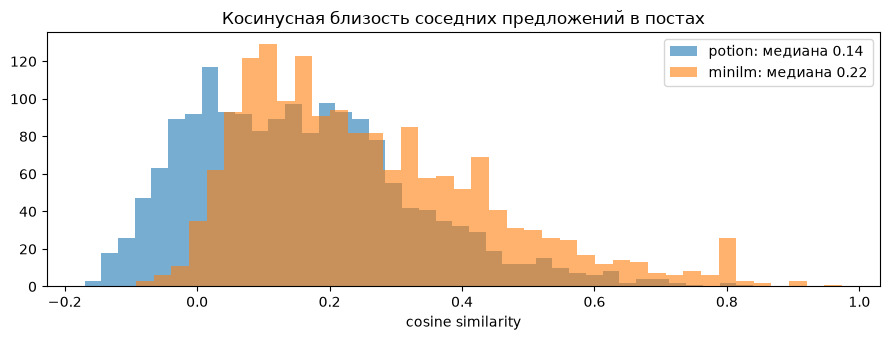

In [12]:
EMBEDDERS = {'potion': 'minishlab/potion-multilingual-128M', 'minilm': 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'}
SPLIT = re.compile(r'(?<=[.!?])\s+|\n+')
p = CACHE / 'sem_sims.pkl'
if p.exists():
    sim_dist, _ = pickle.load(open(p, 'rb'))
else:
    rng = np.random.default_rng(42)
    multi = [d for d in docs_clean if len([s for s in SPLIT.split(d['text']) if len(s) >= 24]) >= 4]
    sample = [multi[i] for i in rng.choice(len(multi), size=min(300, len(multi)), replace=False)]
    sim_dist = {}
    for short, name in EMBEDDERS.items():
        emb = AutoEmbeddings.get_embeddings(name)
        sims = []
        for d in sample:
            sents = [s for s in SPLIT.split(d['text']) if len(s) >= 24]
            E = np.array(emb.embed_batch(sents))
            E = E / np.linalg.norm(E, axis=1, keepdims=True)
            sims += list((E[:-1] * E[1:]).sum(1))
        sim_dist[short] = np.array(sims)
    pickle.dump((sim_dist, None), open(p, 'wb'))

fig, ax = plt.subplots(figsize=(9, 3.5))
for short, sims in sim_dist.items():
    ax.hist(sims, bins=40, alpha=0.6, label=f'{short}: медиана {np.median(sims):.2f}')
ax.set_title('Косинусная близость соседних предложений в постах')
ax.set_xlabel('cosine similarity'); ax.legend(); plt.tight_layout(); plt.show()

Близость очень низкая (медиана 0.14 у potion и 0.22 у MiniLM), а дефолтный порог 0.8 вообще за пределами распределения. Полез в код Chonkie, и оказалось, что в версии 1.7 threshold это не порог косинуса. Чанкер строит кривую близости (каждое предложение против окна из 3 предыдущих), сглаживает её фильтром Савицкого-Голея, ищет локальные минимумы и оставляет те, что проходят по перцентилю threshold. То есть threshold это перцентиль от 0 до 1: чем он выше, тем больше разрезов. Проверил на одном длинном посте:

In [13]:
demo = next(d for d in docs_clean if d['doc_id'] == 'SteamByFree/19153')
for thr in [0.05, 0.2, 0.4, 0.6, 0.8, 0.95]:
    ch = SemanticChunker(embedding_model=EMBEDDERS['potion'], threshold=thr, chunk_size=2048).chunk(demo['text'])
    print(f'threshold={thr}: чанков {len(ch):2d}, токены по чанкам {[c.token_count for c in ch]}')

threshold=0.05: чанков  2, токены по чанкам [422, 27]


threshold=0.2: чанков  4, токены по чанкам [222, 85, 115, 27]


threshold=0.4: чанков  7, токены по чанкам [39, 55, 93, 35, 85, 115, 27]


threshold=0.6: чанков 10, токены по чанкам [39, 15, 40, 93, 35, 85, 66, 42, 7, 27]


threshold=0.8: чанков 13, токены по чанкам [39, 15, 40, 93, 35, 50, 35, 12, 54, 42, 7, 20, 7]


threshold=0.95: чанков 15, токены по чанкам [39, 15, 40, 73, 20, 20, 15, 50, 35, 12, 54, 42, 7, 20, 7]


Так и есть. Поэтому сетку беру по всему диапазону: 0.05, 0.2, 0.4, 0.6, 0.8, 0.95, от почти не резать до резать почти везде, 0.8 это дефолт. Эмбеддеры два: potion-multilingual-128M (статический Model2Vec, очень быстрый) и paraphrase-multilingual-MiniLM-L12-v2 (обычный трансформер). Для лучшего порога каждого ещё пробую skip_window=1, это бывший SDPM: склеивает похожие куски через один.

In [14]:
GRID = [0.05, 0.2, 0.4, 0.6, 0.8, 0.95]
rows = []
for short, name in EMBEDDERS.items():
    for thr in GRID:
        ch, t = cached_chunks(f'sem_{short}_{thr}', lambda: SemanticChunker(embedding_model=name, threshold=thr, chunk_size=256))
        s = summary(evaluate(BM25Index(ch).search, val_q, dup_map))
        rows.append({'embedder': short, 'threshold': thr, 'skip_window': 0, **chunk_stats(ch), 'chunk_time_s': round(t, 1), **s})
sem_table = pd.DataFrame(rows)
for short, name in EMBEDDERS.items():
    best = sem_table[sem_table.embedder == short].sort_values(['recall@5', 'hit@5'], ascending=False).iloc[0]
    thr = float(best.threshold)
    ch, t = cached_chunks(f'sem_{short}_{thr}_skip1', lambda: SemanticChunker(embedding_model=name, threshold=thr, chunk_size=256, skip_window=1))
    s = summary(evaluate(BM25Index(ch).search, val_q, dup_map))
    sem_table.loc[len(sem_table)] = {'embedder': short, 'threshold': thr, 'skip_window': 1, **chunk_stats(ch), 'chunk_time_s': round(t, 1), **s}
sem_table

,embedder,threshold,skip_window,n_chunks,mean,median,std,lt50_%,gt500_%,chunk_time_s,hit@5,recall@5,recall@10,prec@5,mrr
0,potion,0.05,0,1980,132.9,122.0,78.6,8.1,0.0,2.2,0.714,0.649,0.723,0.207,0.722
1,potion,0.20,0,2122,124.0,118.0,66.8,9.8,0.0,2.3,0.750,0.653,0.719,0.221,0.750
2,potion,0.40,0,2380,110.5,109.0,60.1,15.7,0.0,2.4,0.750,0.653,0.689,0.229,0.708
3,potion,0.60,0,2689,97.8,98.0,56.1,23.0,0.0,2.3,0.750,0.653,0.707,0.221,0.714
4,potion,0.80,0,2962,88.8,86.0,54.9,29.4,0.0,2.2,0.750,0.696,0.736,0.236,0.731
5,potion,0.95,0,3137,83.9,78.0,54.1,33.8,0.0,2.3,0.750,0.714,0.736,0.243,0.731
6,minilm,0.05,0,1975,133.2,123.0,78.7,8.9,0.0,33.5,0.714,0.667,0.719,0.221,0.719
7,minilm,0.20,0,2091,125.8,120.0,69.5,11.1,0.0,31.0,0.750,0.653,0.723,0.221,0.750
8,minilm,0.40,0,2303,114.2,111.0,60.0,15.2,0.0,94.4,0.786,0.671,0.741,0.236,0.721
9,minilm,0.60,0,2593,101.5,101.0,55.3,21.6,0.0,122.2,0.786,0.671,0.741,0.243,0.726


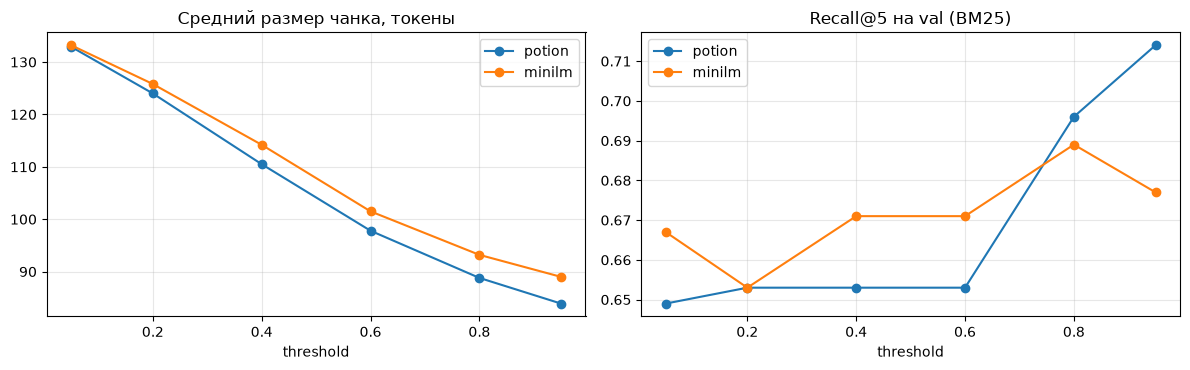

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for short in EMBEDDERS:
    g = sem_table[(sem_table.embedder == short) & (sem_table.skip_window == 0)]
    axes[0].plot(g.threshold, g['mean'], marker='o', label=short)
    axes[1].plot(g.threshold, g['recall@5'], marker='o', label=short)
axes[0].set_title('Средний размер чанка, токены'); axes[1].set_title('Recall@5 на val (BM25)')
for ax in axes:
    ax.set_xlabel('threshold'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Что получилось:
- чем выше порог, тем мельче чанки, у potion средний размер падает со 133 до 84 токенов;
- у potion Recall@5 растёт вместе с числом разрезов, лучший порог 0.95 (0.714). У MiniLM Hit@5 0.786 уже с порога 0.4, но Recall@5 максимум 0.689;
- MiniLM режет в 15-60 раз дольше (30-150 секунд на корпус против 2 у potion), а по полноте не лучше;
- skip_window=1 у potion ничего не поменял (на таком мелком разбиении склеивать нечего), у MiniLM стало чуть хуже.

Насколько разбиение зависит от модели: сравниваю границы чанков у двух эмбеддеров при одинаковом пороге.

In [16]:
pairs = []
for thr in GRID:
    a, _ = cached_chunks(f'sem_potion_{thr}', None)
    b, _ = cached_chunks(f'sem_minilm_{thr}', None)
    def bounds(ch):
        out = {}
        for c in ch:
            out.setdefault(c['doc_id'], []).append(c['text'].strip())
        return out
    ba, bb = bounds(a), bounds(b)
    same = np.mean([ba[d] == bb.get(d) for d in ba])
    multi = [d for d in ba if len(ba[d]) > 1 or len(bb.get(d, [])) > 1]
    same_multi = np.mean([ba[d] == bb.get(d) for d in multi]) if multi else np.nan
    pairs.append({'threshold': thr, 'чанков potion': len(a), 'чанков minilm': len(b),
                  'посты с одинаковым разбиением, %': round(100 * same, 1), 'то же среди разрезанных постов, %': round(100 * same_multi, 1)})
pd.DataFrame(pairs)

,threshold,чанков potion,чанков minilm,"посты с одинаковым разбиением, %","то же среди разрезанных постов, %"
0,0.05,1980,1975,87.0,25.7
1,0.20,2122,2091,86.4,22.2
2,0.40,2380,2303,85.6,18.0
3,0.60,2689,2593,84.0,8.8
4,0.80,2962,2822,84.1,9.2
5,0.95,3137,2957,84.1,9.2


Если считать все посты, разбиение совпадает у 84-87%, но это потому, что короткие посты оба эмбеддера вообще не режут. Среди постов, которые хоть один из них разрезал, одинаково порезано всего 9-26%, и чем выше порог, тем меньше совпадений. То есть модель реально двигает границы, и порог с одной модели на другую не переносится.

Как это выглядит на одном посте (анонсы Summer Game Fest): один и тот же текст при порогах 0.2, 0.6 и 0.95 у обоих эмбеддеров.

In [17]:
viz = next(d for d in docs_clean if d['doc_id'] == 'egs_tg/10449')
for short in EMBEDDERS:
    for thr in [0.2, 0.6, 0.95]:
        ch = SemanticChunker(embedding_model=EMBEDDERS[short], threshold=thr, chunk_size=256).chunk(viz['text'])
        print(f'===== {short}, threshold={thr}: {len(ch)} чанков')
        for i, c in enumerate(ch, 1):
            print(f'[{i}] ' + c.text.replace('\n', ' ')[:150])
        print()

===== potion, threshold=0.2: 5 чанков
[1] Главные анонсы Summer Game Fest 2026  Resident Evil: Code Veronica Remake — 2027 год  Final Fantasy VII Revelation — весна 2027  Stellar Blade: Blood 
[2] The Wolf Among Us 2 — 2027 год  The Wolf Among Us Remastered — конец 2026 года  Control Resonant — 24 сентября 2026  Star Wars: Zero Company — 27 авгу
[3] Gundam Rogue Orbit — 2027 год  Star Wars: Galactic Racer — 6 октября 2026  Sea of Remnants — конец 2026 года  Chronicles: Medieval — конец 2026 года (
[4] Among Us Story: On Guard — дата неизвестна  Sonic Pico Park — 2026 год  Mighty Cuphead Adventure — дата неизвестна  Cuphead 2 — подтверждена разработк
[5] Больше всего внимания зрителей привлекли Resident Evil: Code Veronica Remake, Final Fantasy VII Revelation, Alien: Isolation 2 и новая Stellar Blade.



===== potion, threshold=0.6: 12 чанков
[1] Главные анонсы Summer Game Fest 2026  Resident Evil: Code Veronica Remake — 2027 год  Final Fantasy VII Revelation — весна 2027  
[2] Stellar Blade: Blood Rain — дата неизвестна  
[3] Alien: Isolation 2 — дата неизвестна  
[4] Guild Wars 3 — дата неизвестна  Attack on Titan 3 — дата неизвестна  Teenage Mutant Ninja Turtles: The Last Ronin — дата неизвестна  
[5] The Wolf Among Us 2 — 2027 год  The Wolf Among Us Remastered — конец 2026 года  Control Resonant — 24 сентября 2026  Star Wars: Zero Company — 27 авгу
[6] Clutch — весна 2027  Hot Wheels Infinite Rush — 24 сентября 2026  End of Abyss — 1 октября 2026  Lords of the Fallen II — осень 2026  
[7] Monster Hunter Wilds: Ascendance — 2027 год  Stranger Than Heaven — 15 января 2027  
[8] SAW: Genesis — дата неизвестна  Crossfire — дата неизвестна  Blood Message — дата неизвестна  genATLAS — дата неизвестна  
[9] Gundam Rogue Orbit — 2027 год  Star Wars: Galactic Racer — 6 октября 2026  Sea of 

===== potion, threshold=0.95: 19 чанков
[1] Главные анонсы Summer Game Fest 2026  Resident Evil: Code Veronica Remake — 2027 год  Final Fantasy VII Revelation — весна 2027  
[2] Stellar Blade: Blood Rain — дата неизвестна  
[3] Alien: Isolation 2 — дата неизвестна  
[4] Guild Wars 3 — дата неизвестна  Attack on Titan 3 — дата неизвестна  Teenage Mutant Ninja Turtles: The Last Ronin — дата неизвестна  
[5] The Wolf Among Us 2 — 2027 год  The Wolf Among Us Remastered — конец 2026 года  Control Resonant — 24 сентября 2026  
[6] Star Wars: Zero Company — 27 августа 2026  The Blood of Dawnwalker — 3 сентября 2026  
[7] Mafia: The Old Country — Man of Honor — 14 августа 2026  
[8] Clutch — весна 2027  
[9] Hot Wheels Infinite Rush — 24 сентября 2026  End of Abyss — 1 октября 2026  
[10] Lords of the Fallen II — осень 2026  
[11] Monster Hunter Wilds: Ascendance — 2027 год  
[12] Stranger Than Heaven — 15 января 2027  
[13] SAW: Genesis — дата неизвестна  
[14] Crossfire — дата неизвестна  Bl

===== minilm, threshold=0.2: 4 чанков
[1] Главные анонсы Summer Game Fest 2026  Resident Evil: Code Veronica Remake — 2027 год  Final Fantasy VII Revelation — весна 2027  Stellar Blade: Blood 
[2] Control Resonant — 24 сентября 2026  Star Wars: Zero Company — 27 августа 2026  The Blood of Dawnwalker — 3 сентября 2026  Mafia: The Old Country — Ma
[3] Among Us Story: On Guard — дата неизвестна  Sonic Pico Park — 2026 год  Mighty Cuphead Adventure — дата неизвестна  Cuphead 2 — подтверждена разработк
[4] Больше всего внимания зрителей привлекли Resident Evil: Code Veronica Remake, Final Fantasy VII Revelation, Alien: Isolation 2 и новая Stellar Blade.



===== minilm, threshold=0.6: 9 чанков
[1] Главные анонсы Summer Game Fest 2026  Resident Evil: Code Veronica Remake — 2027 год  Final Fantasy VII Revelation — весна 2027  Stellar Blade: Blood 
[2] Control Resonant — 24 сентября 2026  Star Wars: Zero Company — 27 августа 2026  The Blood of Dawnwalker — 3 сентября 2026  Mafia: The Old Country — Ma
[3] Clutch — весна 2027  Hot Wheels Infinite Rush — 24 сентября 2026  End of Abyss — 1 октября 2026  
[4] Lords of the Fallen II — осень 2026  Monster Hunter Wilds: Ascendance — 2027 год  Stranger Than Heaven — 15 января 2027  SAW: Genesis — дата неизвестн
[5] Blood Message — дата неизвестна  genATLAS — дата неизвестна  Gundam Rogue Orbit — 2027 год  Star Wars: Galactic Racer — 6 октября 2026  Sea of Remnant
[6] 1666: Amsterdam — конец 2026 года (ранний доступ)  
[7] Among Us Story: On Guard — дата неизвестна  
[8] Sonic Pico Park — 2026 год  Mighty Cuphead Adventure — дата неизвестна  Cuphead 2 — подтверждена разработка, без даты 
[9] Больше в

===== minilm, threshold=0.95: 14 чанков
[1] Главные анонсы Summer Game Fest 2026  Resident Evil: Code Veronica Remake — 2027 год  Final Fantasy VII Revelation — весна 2027  
[2] Stellar Blade: Blood Rain — дата неизвестна  Alien: Isolation 2 — дата неизвестна  Guild Wars 3 — дата неизвестна  Attack on Titan 3 — дата неизвестна
[3] Teenage Mutant Ninja Turtles: The Last Ronin — дата неизвестна  The Wolf Among Us 2 — 2027 год  The Wolf Among Us Remastered — конец 2026 года  
[4] Control Resonant — 24 сентября 2026  Star Wars: Zero Company — 27 августа 2026  The Blood of Dawnwalker — 3 сентября 2026  Mafia: The Old Country — Ma
[5] Clutch — весна 2027  Hot Wheels Infinite Rush — 24 сентября 2026  End of Abyss — 1 октября 2026  
[6] Lords of the Fallen II — осень 2026  Monster Hunter Wilds: Ascendance — 2027 год  Stranger Than Heaven — 15 января 2027  SAW: Genesis — дата неизвестн
[7] Crossfire — дата неизвестна  
[8] Blood Message — дата неизвестна  
[9] genATLAS — дата неизвестна  Gundam

На пороге 0.2 potion собрал пост в 5 кусков, и в одном чанке анонсы десятка игр сразу. На 0.6 уже 12 кусков, на 0.95 их 19, и почти каждая игра или пара игр идёт отдельно. Для поиска это как раз хорошо, вопрос обычно про одну игру, поэтому у potion полнота и растёт с порогом. MiniLM на тех же порогах режет этот пост реже (4, 9 и 14 кусков) и ставит границы в других местах, например на 0.6 у MiniLM Blood Message, genATLAS и Gundam в одном чанке, а у potion Gundam уже в отдельном.

Итог по семантическому: на этом корпусе он не лучше простого sentence 128 (Recall@5 0.714 против 0.707, но Hit@5 0.750 против 0.786), а стоит дороже. Посты короткие, и почти каждый про одну тему, семантике тут негде развернуться. Реально помогает он только на длинных постах-списках вроде этого. Если и брать, то potion с высоким порогом, он быстрый.

## 4. ParentDocumentRetriever на BGE-M3

Схема: индексирую мелкие дочерние куски, ищу по ним эмбеддингами BGE-M3, а возвращаю родителя, которому принадлежит найденный кусок (без повторов). Комбинации:
- родитель целый пост, ребёнок 64 токена;
- родитель целый пост, ребёнок 128;
- родитель 256 токенов, ребёнок 64;
- родитель 512, ребёнок 128.

Сравниваю с лучшим простым чанкером (sentence 128) и на BM25, и на том же BGE-M3, чтобы сравнение было честным по модели.

In [18]:
_bge = None
def bge():
    global _bge
    if _bge is None:
        _bge = SentenceTransformer('BAAI/bge-m3', device=DEVICE)
        _bge.max_seq_length = 512
    return _bge

EMB_TIMES_PATH = CACHE / 'emb_times.json'
EMB_TIMES = json.loads(EMB_TIMES_PATH.read_text()) if EMB_TIMES_PATH.exists() else {}
def embed(texts, key):
    p = CACHE / 'emb' / f'{key}.npy'
    if p.exists():
        return np.load(p), EMB_TIMES.get(key)
    t0 = time.time()
    E = bge().encode(texts, batch_size=32, normalize_embeddings=True, show_progress_bar=False, convert_to_numpy=True)
    np.save(p, E.astype(np.float32))
    EMB_TIMES[key] = round(time.time() - t0, 1)
    EMB_TIMES_PATH.write_text(json.dumps(EMB_TIMES, indent=1))
    return E, EMB_TIMES[key]

class DenseIndex:
    def __init__(self, chunks, key):
        self.chunks = chunks
        self.E, self.build_time = embed([c['text'] for c in chunks], key)
    def search(self, q, k=10, mask=None):
        s = self.E @ bge().encode([q], normalize_embeddings=True, convert_to_numpy=True)[0]
        if mask is not None:
            s = np.where(mask, s, -np.inf)
        idx = np.argsort(-s)[:k]
        return [self.chunks[i] for i in idx if np.isfinite(s[i])]

simple = chunker_table[chunker_table.chunker.str.match('token|sentence')].sort_values(['hit@5', 'recall@5', 'mrr'], ascending=False)
BEST = simple.iloc[0].chunker
best_chunks = CH[BEST]
print('лучший простой чанкер по BM25 на val:', BEST)

лучший простой чанкер по BM25 на val: sentence_128


In [19]:
def by_type(df):
    return df.groupby('type')[['hit@5', 'recall@5']].mean().round(3)

dense_rows, type_tables = [], {}
bm_best = BM25Index(best_chunks)
e = evaluate(bm_best.search, val_q, dup_map)
dense_rows.append({'config': f'BM25 | {BEST}', **summary(e)})
type_tables['BM25 ' + BEST] = by_type(e)

dn_best = DenseIndex(best_chunks, f'dense_{BEST}')
e = evaluate(dn_best.search, val_q, dup_map)
dense_rows.append({'config': f'BGE-M3 | {BEST}', **summary(e)})
type_tables['BGE-M3 ' + BEST] = by_type(e)

def build_pc(parent_size, child_size):
    if parent_size == 'post':
        parents = [{'doc_id': d['doc_id'], 'text': d['text']} for d in docs_clean if d['text'].strip()]
    else:
        parents = chunk_docs(docs_clean, TokenChunker(tokenizer='cl100k_base', chunk_size=parent_size))
    cc = TokenChunker(tokenizer='cl100k_base', chunk_size=child_size)
    children = [{'pi': pi, 'doc_id': p['doc_id'], 'text': c.text} for pi, p in enumerate(parents) for c in cc.chunk(p['text'])]
    E, _ = embed([c['text'] for c in children], f'pc_{parent_size}_{child_size}')
    pis = np.array([c['pi'] for c in children])
    def search(q, k=10):
        s = E @ bge().encode([q], normalize_embeddings=True, convert_to_numpy=True)[0]
        seen = []
        for i in np.argsort(-s)[:300]:
            if pis[i] not in seen:
                seen.append(pis[i])
                if len(seen) == k:
                    break
        return [parents[p] for p in seen]
    return parents, children, search

PC = {}
for ps, cs in [('post', 64), ('post', 128), (256, 64), (512, 128)]:
    parents, children, search = build_pc(ps, cs)
    name = f'parent={ps} child={cs}'
    PC[name] = (parents, children, search)
    e = evaluate(search, val_q, dup_map)
    dense_rows.append({'config': f'BGE-M3 parent/child | {name}', 'parents': len(parents), 'children': len(children), **summary(e)})
    type_tables[name] = by_type(e)
dense_table = pd.DataFrame(dense_rows)
dense_table

,config,hit@5,recall@5,recall@10,prec@5,mrr,parents,children
0,BM25 | sentence_128,0.786,0.707,0.741,0.271,0.768,NaN,NaN
1,BGE-M3 | sentence_128,0.786,0.682,0.741,0.236,0.726,NaN,NaN
2,BGE-M3 parent/child | parent=post child=64,0.750,0.682,0.693,0.207,0.690,1622.0,4932.0
3,BGE-M3 parent/child | parent=post child=128,0.750,0.676,0.711,0.207,0.696,1622.0,2870.0
4,BGE-M3 parent/child | parent=256 child=64,0.750,0.682,0.693,0.214,0.690,1852.0,4932.0
5,BGE-M3 parent/child | parent=512 child=128,0.750,0.676,0.711,0.207,0.696,1716.0,2870.0


In [20]:
pd.concat(type_tables, axis=1)

BM25 sentence_128          BGE-M3 sentence_128          parent=post child=64          parent=post child=128          parent=256 child=64          parent=512 child=128         
                      hit@5 recall@5               hit@5 recall@5                hit@5 recall@5                 hit@5 recall@5               hit@5 recall@5                hit@5 recall@5
type                                                                                                                                                                                     
abstract              0.143    0.018               0.143    0.036                0.143    0.036                 0.143    0.036               0.143    0.036                0.143    0.036
composite             1.000    0.867               1.000    0.833                0.900    0.783                 0.900    0.817               0.900    0.783                0.900    0.817
factual               1.000    1.000               1.000    0.955                1.000    1.000                 1.000    0.955               1.000    1.000                1.000    0.955

Что видно:
- BGE-M3 на sentence 128 по Recall@5 даже немного хуже BM25 (0.682 против 0.707). В вопросах много названий игр и цифр, а на точных совпадениях BM25 сильнее;
- parent/child в среднем не лучше обычного dense, Hit@5 0.750 против 0.786;
- но по типам вопросов картина разная. На фактических маленький ребёнок на 64 токена даёт Recall@5 1.0 против 0.955 у обычного dense: маленький кусок точнее совпадает с конкретным вопросом, а отдаём всё равно весь пост с контекстом;
- на составных parent/child хуже (0.783 против 0.833). Похоже, мелкий кусок совпадает с одной половиной вопроса, и второй нужный пост проигрывает чужим постам с похожим кусочком. Но тут всего 10 вопросов, разница в 1-2 вопроса;
- абстрактные проваливаются у всех (Hit@5 0.14): у них по 3-9 нужных постов, и топ-5 их физически не вмещает. Тут поможет только агрегация или реранкинг, это следующие КТ.

Ещё важно: метрики у меня по постам, а главный плюс parent/child это больше контекста для генерации. Это будет видно в КТ5, когда начнём отвечать по найденному.

Ещё проверил предобработку не только на BM25, но и на BGE-M3 (тот же token 512):

In [21]:
STEP_KEYS = {'1a удаление HTML': '1a_html', '1b подписи и служебные посты': '1b_boilerplate',
             '3a эмодзи: удалить все': '3a_emoji_remove_all', '3b эмодзи: keycap в цифры, остальные удалить': '3b_emoji_keycap_digits'}
rows = []
for st, key in STEP_KEYS.items():
    ch = chunk_docs([d for d in steps[st] if d['text'].strip()], token512)
    rows.append({'шаг': st, **summary(evaluate(DenseIndex(ch, f'dense_step_{key}').search, val_q))})
pd.DataFrame(rows)

,шаг,hit@5,recall@5,recall@10,prec@5,mrr
0,1a удаление HTML,0.750,0.662,0.698,0.207,0.689
1,1b подписи и служебные посты,0.786,0.680,0.698,0.214,0.689
2,3a эмодзи: удалить все,0.714,0.658,0.711,0.200,0.665
3,"3b эмодзи: keycap в цифры, остальные удалить",0.714,0.658,0.711,0.200,0.665


Для эмбеддингов картина другая. Удаление подписей помогло (Hit@5 0.750 до 0.786, Recall@5 0.662 до 0.680), то есть одинаковый хвост у всех постов эмбеддингам мешал, как я и думал. А удаление эмодзи немного ухудшило, Hit@5 0.786 до 0.714. Посмотрел, какие вопросы поменялись:

In [22]:
a = evaluate(DenseIndex(chunk_docs([d for d in steps['1b подписи и служебные посты'] if d['text'].strip()], token512), 'dense_step_1b_boilerplate').search, val_q).set_index('qid')
b = evaluate(DenseIndex(chunk_docs([d for d in steps['3a эмодзи: удалить все'] if d['text'].strip()], token512), 'dense_step_3a_emoji_remove_all').search, val_q).set_index('qid')
for qid in a.index[a['hit@5'] != b['hit@5']]:
    g = next(x for x in val_q if x['qid'] == qid)
    print(qid, g['type'], '|', g['question'][:90], '| hit@5 с эмодзи:', a.loc[qid, 'hit@5'], 'без:', b.loc[qid, 'hit@5'], '| mrr:', round(a.loc[qid, 'mrr'], 2), '->', round(b.loc[qid, 'mrr'], 2))

q28 composite | Какие игры раздавались бесплатно в Epic Games Store в период с 14 по 28 мая 2026 года? | hit@5 с эмодзи: 1.0 без: 0.0 | mrr: 0.2 -> 0.17
q37 abstract | Какие жанры игр наиболее часто представлены в тематических подборках канала? | hit@5 с эмодзи: 1.0 без: 0.0 | mrr: 0.25 -> 0.0


Это два вопроса и оба на самой границе: у q28 нужный пост сдвинулся с 5 места на 6, q37 тот же нестабильный абстрактный. Так что честно: удаление эмодзи эмбеддингам не помогло и, может, чуть мешает, но разница на уровне шума. В КТ3, где будет dense, попробую вариант с эмодзи.

## 5. Метаданные

Для каждого чанка sentence 128 достаю:
- структурные: дата, канал, длина поста в токенах, позиция чанка в посте (pos из n_parts);
- контентные: топ-5 ключевых слов по TF-IDF (стоп-слова из КТ1), язык по доле кириллицы, тип контента правилами: новость, скидка, раздача, розыгрыш, реклама;
- качество: noise_score, доля токенов без букв.

In [23]:
STOP = set(open(DATA / 'stop_ru.txt', encoding='utf-8').read().split())
doc_len = {d['doc_id']: ntok(d['text']) for d in docs_clean}
doc_text = {d['doc_id']: d['text'] for d in docs_clean}

def content_type(t):
    t = t.lower()
    if re.search(r'розыгрыш|победител|конкурс', t): return 'contest'
    if re.search(r'реклама|erid|igm\.gg|промокод', t): return 'ad'
    if re.search(r'получила скидку|покупаем за|акция продлится|топ \d+ игр до|\| -\d+% \||-\d+%\s*\|', t): return 'deal'
    if re.search(r'раздач|бесплатно|забрать', t): return 'giveaway'
    return 'news'

def lang(t):
    cyr, lat = len(re.findall('[А-Яа-яЁё]', t)), len(re.findall('[A-Za-z]', t))
    share = cyr / max(1, cyr + lat)
    return 'ru' if share > 0.6 else 'en' if share < 0.4 else 'mixed'

tf = TfidfVectorizer(max_features=30000, min_df=2, max_df=0.3, token_pattern=r'(?u)\b[а-яёa-z][а-яёa-z0-9]{2,}\b', stop_words=list(STOP))
M = tf.fit_transform([c['text'].lower() for c in best_chunks])
vocab = np.array(tf.get_feature_names_out())
for i, c in enumerate(best_chunks):
    row = M.getrow(i)
    c['keywords'] = list(vocab[row.indices[np.argsort(-row.data)][:5]])
    c['doc_len'] = doc_len[c['doc_id']]
    c['ctype'] = content_type(doc_text[c['doc_id']])
    c['lang'] = lang(c['text'])
    c['noise_score'] = round(noise_share([c['text']]), 3)

meta = pd.DataFrame([{k: c[k] for k in ['doc_id', 'source', 'date', 'pos', 'n_parts', 'doc_len', 'ctype', 'lang', 'noise_score', 'keywords']} for c in best_chunks])
print('тип контента:', meta.ctype.value_counts().to_dict())
print('язык:', meta.lang.value_counts().to_dict())
print('noise_score: медиана', meta.noise_score.median(), '| > 0.4:', (meta.noise_score > 0.4).sum())
print('чанки с noise_score > 0.4 по типам:', meta[meta.noise_score > 0.4].ctype.value_counts().to_dict())
meta.sample(6, random_state=1)

тип контента: {'news': 1746, 'deal': 992, 'giveaway': 143, 'contest': 47, 'ad': 10}
язык: {'ru': 2853, 'mixed': 60, 'en': 25}
noise_score: медиана 0.105 | > 0.4: 441
чанки с noise_score > 0.4 по типам: {'deal': 427, 'news': 9, 'giveaway': 4, 'contest': 1}


,doc_id,source,date,pos,n_parts,doc_len,ctype,lang,noise_score,keywords
1268,egs_tg/9907,egs_tg,2026-01-27 06:49:35+00:00,0,1,45,news,ru,0.133,"[deadlock, герой, пиковый, достиг, появился]"
2719,SteamByFree/17964,SteamByFree,2026-07-10 10:50:05+00:00,0,5,603,deal,ru,0.512,"[зоопарка, watch, zoo, франциско, хакерский]"
2710,SteamByFree/17979,SteamByFree,2026-07-10 19:20:03+00:00,1,2,195,deal,ru,0.214,"[защищать, любви, живых, ради, своей]"
2028,SteamByFree/19035,SteamByFree,2026-08-26 09:03:17+00:00,4,7,741,deal,ru,0.278,"[рации, уничтожение, солнцем, динамичное, улицах]"
351,egs_tg/10787,egs_tg,2026-08-10 08:41:04+00:00,1,2,140,news,ru,0.048,"[растут, готовые, модули, производителей, цене]"
2513,SteamByFree/18286,SteamByFree,2026-07-24 15:55:02+00:00,1,2,152,deal,ru,0.545,"[июля, продлится, акция]"


Почти всё на русском, английских чанков единицы (названия игр, списки). По типам больше всего новостей и скидок, это и есть два канала.

Два сценария применения:
1. фильтр при поиске. Простой роутер по словам в вопросе: если про цену или скидку, ищу только среди скидок, если про раздачу, среди раздач и скидок, иначе среди новостей и раздач (розыгрыши и рекламу убираю). И отдельно фильтр мусорных чанков, noise_score < 0.4;
2. prepend: перед текстом чанка дописываю строку с каналом, датой, типом и ключевыми словами и индексирую уже так.

In [24]:
def route(q):
    ql = q.lower()
    if re.search(r'скидк|цен[аеуы]|стоит|стоим|руб|₽|дешевле|подборк|акци', ql): return {'deal'}
    if re.search(r'раздач|бесплатн|забрать', ql): return {'giveaway', 'deal'}
    return {'news', 'giveaway'}

ctypes = np.array([c['ctype'] for c in best_chunks])
noise = np.array([c['noise_score'] for c in best_chunks])
SRC = {'egs_tg': 'Epic Games Store', 'SteamByFree': 'Халявный Steam'}
CT = {'news': 'новость', 'deal': 'скидка', 'giveaway': 'раздача', 'contest': 'розыгрыш', 'ad': 'реклама'}
prepended = [dict(c, text=f"Канал: {SRC[c['source']]}. Дата: {str(c['date'])[:10]}. Тип: {CT[c['ctype']]}. Ключевые слова: {', '.join(c['keywords'])}.\n{c['text']}") for c in best_chunks]

rows = []
for rname, idx in [('BM25', bm_best), ('BGE-M3', dn_best)]:
    rows.append({'retriever': rname, 'scenario': 'без метаданных', **summary(evaluate(idx.search, val_q, dup_map))})
    by_type_filter = lambda q, k, idx=idx: idx.search(q, k, mask=np.isin(ctypes, list(route(q))))
    rows.append({'retriever': rname, 'scenario': 'фильтр по типу контента', **summary(evaluate(by_type_filter, val_q, dup_map))})
    noise_filter = lambda q, k, idx=idx: idx.search(q, k, mask=noise < 0.4)
    rows.append({'retriever': rname, 'scenario': 'фильтр noise_score < 0.4', **summary(evaluate(noise_filter, val_q, dup_map))})
bm_pre = BM25Index(prepended)
dn_pre = DenseIndex(prepended, f'dense_prepend_{BEST}')
rows.append({'retriever': 'BM25', 'scenario': 'prepend метаданных', **summary(evaluate(bm_pre.search, val_q, dup_map))})
rows.append({'retriever': 'BGE-M3', 'scenario': 'prepend метаданных', **summary(evaluate(dn_pre.search, val_q, dup_map))})
meta_table = pd.DataFrame(rows)
meta_table

,retriever,scenario,hit@5,recall@5,recall@10,prec@5,mrr
0,BM25,без метаданных,0.786,0.707,0.741,0.271,0.768
1,BM25,фильтр по типу контента,0.750,0.689,0.705,0.243,0.732
2,BM25,фильтр noise_score < 0.4,0.750,0.671,0.693,0.257,0.750
3,BGE-M3,без метаданных,0.786,0.682,0.741,0.236,0.726
4,BGE-M3,фильтр по типу контента,0.750,0.646,0.710,0.207,0.694
5,BGE-M3,фильтр noise_score < 0.4,0.750,0.676,0.693,0.236,0.714
6,BM25,prepend метаданных,0.786,0.719,0.750,0.271,0.730
7,BGE-M3,prepend метаданных,0.786,0.693,0.711,0.264,0.726


In [25]:
pd.DataFrame([{'qid': g['qid'], 'type': g['type'], 'вопрос': g['question'][:70], 'роутер': sorted(route(g['question'])),
               'типы релевантных постов': sorted({content_type(doc_text[dup_map.get(d, d)]) for d in g['relevant_doc_ids'] if dup_map.get(d, d) in doc_text})}
              for g in val_q])

,qid,type,вопрос,роутер,типы релевантных постов
0,q01,factual,"Эй, кто знает какие 3 игры добавят в PS Plus в январе 2026?","[giveaway, news]",[giveaway]
1,q02,factual,"Сколько магазинов, ТЦ и небоскрёбов с рабочими лифтами якобы будет в г","[giveaway, news]",[news]
2,q03,factual,На какой год изначально планировался выход PS6?,"[giveaway, news]",[news]
3,q04,factual,Сколько лет уже разрабатывается новый проект Santa Monica Studio под р,"[giveaway, news]",[news]
4,q05,factual,До какого числа можно бесплатно забрать Bloons TD 6 в Epic Games Store,"[deal, giveaway]",[giveaway]
5,q07,factual,Сколько часов в месяц пользователи проводят в Roblox по данным аналити,"[giveaway, news]",[news]
6,q08,factual,Сколько раз игроки погладили котов в ассасин кред шэдоус за год?,"[giveaway, news]",[news]
7,q09,factual,"Чё там депутат Михаил Иванов говорил, когда хотел запретить GTA в Росс","[giveaway, news]",[news]
8,q11,factual,Что Sony запатентовала в свём гейпаде DualSense?,"[giveaway, news]",[news]
9,q13,factual,Скидка Beholder 3 Steam,[deal],[deal]


Что получилось:
- фильтр по типу контента сделал хуже, prec@5 упал с 0.271 до 0.243. Разобрался почему: у q22 про Демофест оба нужных поста попали в тип розыгрыш, потому что в новости мимоходом упоминается розыгрыш призов, и фильтр их выкинул. Сам роутер при этом почти везде угадал, ошиблась именно разметка постов. Вывод: фильтр по метаданным полезен ровно настолько, насколько точны сами метаданные, а классификация по ключевым словам на таких новостях ошибается;
- фильтр по noise_score тоже ухудшил. Он выкинул 441 чанк (15%), и 427 из них это куски подборок со скидками: там много цен и цифр, поэтому высокая доля неалфавитных токенов, но это нормальный текст, а не мусор. Для такого корпуса порог 0.4 слишком жёсткий;
- prepend немного помог: у BM25 Recall@5 0.707 до 0.719, у BGE-M3 0.682 до 0.693 и prec@5 0.236 до 0.264. Ключевые слова и тип добавляют совпадений с вопросом. MRR у BM25 при этом просел, так что эффект небольшой.

## 6. LLM-обработка чанков

Это самое дорогое, поэтому делаю на подкорпусе, задание это разрешает. Подкорпус 500 постов: все посты, которые в золотом наборе релевантные (90 штук), плюс 410 случайных как фон, чтобы поиску было из чего ошибаться. Все варианты (без LLM, с резюме, с вопросами) считаю на одном и том же подкорпусе, так что между собой сравнение честное. На маленьком индексе искать проще, поэтому абсолютные цифры тут выше, чем на полном корпусе, и с основной таблицей я их напрямую не сравниваю.

Модель Claude Sonnet 4.6, temperature 0. Варианты:
- резюме: 1-2 предложения вместо текста чанка;
- вопросы в стиле HyDE: 3 вопроса на чанк, индексирую вопросы вместо текста (чанк находится, если похож хоть один его вопрос). И ещё текст плюс вопросы вместе.

In [26]:
LLM_MODEL = 'claude-sonnet-4-6'
PRICE_IN, PRICE_OUT = 3 / 1e6, 15 / 1e6
SUM_PROMPT = '''Сделай короткое резюме поста из Telegram-канала про игры: 1-2 предложения, о чём пост. Верни только резюме.

Пост:
{text}'''
Q_PROMPT = '''Придумай 3 разных вопроса, на которые отвечает этот пост из Telegram-канала про игры, так, как их задал бы пользователь поиска. Верни только вопросы, каждый с новой строки, без нумерации.

Пост:
{text}'''

rel_all = {dup_map.get(d, d) for g in gold for d in g['relevant_doc_ids']}
rest = [d['doc_id'] for d in docs_clean if d['doc_id'] not in rel_all]
rng = np.random.default_rng(42)
sub_ids = set(rel_all) | set(rng.choice(rest, size=500 - len(rel_all), replace=False))
sub = [c for c in best_chunks if c['doc_id'] in sub_ids]
print('подкорпус:', len(sub_ids), 'постов, из них релевантных', len(rel_all), '|', len(sub), 'чанков')
print('доля каналов в подкорпусе:', pd.Series([d.split('/')[0] for d in sub_ids]).value_counts(normalize=True).round(2).to_dict())
print('доля каналов во всём корпусе:', pd.Series([d['source'] for d in docs_clean]).value_counts(normalize=True).round(2).to_dict())

подкорпус: 500 постов, из них релевантных 90 | 933 чанков
доля каналов в подкорпусе: {'egs_tg': 0.63, 'SteamByFree': 0.37}
доля каналов во всём корпусе: {'egs_tg': 0.61, 'SteamByFree': 0.39}


In [27]:
_client = None
def client():
    global _client
    if _client is None:
        _client = anthropic.Anthropic()
    return _client

def llm(kind, c):
    p = CACHE / 'llm' / f"{kind}__{c['doc_id'].replace('/', '_')}__{c['pos']}.json"
    if p.exists():
        return json.loads(p.read_text(encoding='utf-8'))
    prompt = (SUM_PROMPT if kind == 'summary' else Q_PROMPT).replace('{text}', c['text'])
    t0 = time.time()
    r = client().messages.create(model=LLM_MODEL, max_tokens=400, temperature=0, messages=[{'role': 'user', 'content': prompt}])
    out = {'text': r.content[0].text.strip(), 'in': r.usage.input_tokens, 'out': r.usage.output_tokens, 'sec': round(time.time() - t0, 2)}
    p.write_text(json.dumps(out, ensure_ascii=False), encoding='utf-8')
    return out

cost = {}
for kind in ['summary', 'questions']:
    with ThreadPoolExecutor(12) as ex:
        outs = list(ex.map(lambda c: llm(kind, c), sub))
    for c, o in zip(sub, outs):
        c[kind] = o['text']
    tin, tout = sum(o['in'] for o in outs), sum(o['out'] for o in outs)
    cost[kind] = {'вызовов': len(outs), 'input токенов': tin, 'output токенов': tout, 'стоимость $': round(tin * PRICE_IN + tout * PRICE_OUT, 2),
                  'сумма времени вызовов, с': round(sum(o['sec'] for o in outs), 1), 'на чанк, с': round(np.mean([o['sec'] for o in outs]), 2)}
pd.DataFrame(cost).T

,вызовов,input токенов,output токенов,стоимость $,"сумма времени вызовов, с","на чанк, с"
summary,933.0,132691.0,58045.0,1.27,1929.4,2.07
questions,933.0,160681.0,54303.0,1.30,1935.5,2.07


Резюме обошлись в $1.27, вопросы в $1.30, всего $2.57 за 933 чанка. Один вызов в среднем 2 секунды, на каждый вариант ушло около 1930 секунд вызовов, в 12 потоков это примерно 3 минуты. Примеры того, что получилось:

In [28]:
for c in sub[:3]:
    print('ЧАНК:', c['text'][:200].replace('\n', ' '))
    print('РЕЗЮМЕ:', c['summary'])
    print('ВОПРОСЫ:', c['questions'].replace('\n', ' | '))
    print()

ЧАНК: Xbox может вложить сотни миллионов в новую игру Кодзимы По данным The Game Business, бюджет Physint якобы может составить около $400 млн. Однако журналист Джейсон Шрайер утверждает, что эта цифра завы
РЕЗЮМЕ: Xbox может инвестировать сотни миллионов долларов в новую игру Хидео Кодзимы Physint, однако реальный бюджет проекта остаётся неизвестным — журналисты расходятся в оценках.
ВОПРОСЫ: Сколько стоит новая игра Кодзимы Physint | Кто финансирует Physint Кодзима | Джейсон Шрайер опроверг бюджет Physint

ЧАНК: Пираты отказались пиратить Control Resonant На тематических форумах игроки начали призывать не скачивать взломанную версию, а официально купить новую игру Remedy и поддержать студию. 
РЕЗЮМЕ: Игроки на пиратских форумах призывают не скачивать взломанную версию Control Resonant, а купить игру официально, чтобы поддержать Remedy.
ВОПРОСЫ: Почему пираты не взламывают Control Resonant | Стоит ли покупать Control Resonant или можно скачать бесплатно | Как игровое сообщество поддер

In [29]:
summ = [dict(c, text=c['summary']) for c in sub]
qunits = [dict(c, text=q.strip()) for c in sub for q in c['questions'].split('\n') if q.strip()]
both = [dict(c) for c in sub] + qunits
VARIANTS = [('текст чанка', sub), ('резюме вместо текста', summ), ('вопросы вместо текста', qunits), ('текст + вопросы', both)]

def unique_chunks(index):
    def search(q, k=10):
        out, seen = [], set()
        for c in index.search(q, 200):
            key = (c['doc_id'], c['pos'])
            if key not in seen:
                seen.add(key)
                out.append(c)
                if len(out) == k:
                    break
        return out
    return search

llm_rows, llm_types, LLM_SEARCH = [], {}, {}
for rname in ['BM25', 'BGE-M3']:
    for i, (vname, units) in enumerate(VARIANTS):
        idx = BM25Index(units) if rname == 'BM25' else DenseIndex(units, f'sub_{BEST}_{i}')
        search = unique_chunks(idx)
        LLM_SEARCH[(rname, vname)] = search
        e = evaluate(search, val_q, dup_map)
        llm_rows.append({'retriever': rname, 'variant': vname, 'единиц в индексе': len(units), **summary(e)})
        llm_types[(rname, vname)] = e.groupby('type')['recall@5'].mean().round(3)
llm_table = pd.DataFrame(llm_rows)
llm_table

,retriever,variant,единиц в индексе,hit@5,recall@5,recall@10,prec@5,mrr
0,BM25,текст чанка,933,0.821,0.750,0.776,0.300,0.803
1,BM25,резюме вместо текста,933,0.714,0.649,0.685,0.250,0.661
2,BM25,вопросы вместо текста,2722,0.821,0.643,0.710,0.271,0.685
3,BM25,текст + вопросы,3655,0.786,0.661,0.741,0.271,0.749
4,BGE-M3,текст чанка,933,0.786,0.717,0.763,0.293,0.748
5,BGE-M3,резюме вместо текста,933,0.821,0.688,0.730,0.286,0.724
6,BGE-M3,вопросы вместо текста,2722,0.786,0.646,0.751,0.264,0.709
7,BGE-M3,текст + вопросы,3655,0.786,0.682,0.751,0.279,0.724


In [30]:
pd.DataFrame(llm_types).T

type                          abstract  composite  factual
BM25   текст чанка               0.071      0.950    1.000
       резюме вместо текста      0.000      0.817    0.909
       вопросы вместо текста     0.050      0.717    0.955
       текст + вопросы           0.050      0.767    0.955
BGE-M3 текст чанка               0.036      0.883    1.000
       резюме вместо текста      0.085      0.867    0.909
       вопросы вместо текста     0.036      0.733    0.955
       текст + вопросы           0.036      0.833    0.955

Что получилось:
- резюме на BM25 сильно хуже (Recall@5 0.750 до 0.649): из резюме пропадают конкретные названия и цифры, а BM25 ищет именно по ним;
- на BGE-M3 резюме даёт ровно то, что предполагалось: на фактических хуже (Recall@5 1.0 до 0.909), на абстрактных лучше (Hit@5 0.143 до 0.429). Резюме описывает, о чём пост, и вопрос про тему с ним лучше совпадает. В среднем Hit@5 даже выше (0.821), но Recall@5 ниже;
- вопросы вместо текста хуже везде, особенно на составных (у BM25 Recall@5 0.950 до 0.717): модель спрашивает про главное в посте, а составной вопрос часто цепляет второстепенную деталь;
- текст плюс вопросы тоже не лучше просто текста.

Окупается ли. На всём корпусе это около 2900 чанков, примерно $4 и минут 8-9 на каждый вариант, а прироста полноты нет. Плюс только у резюме на абстрактных вопросах в dense, но таких вопросов мало, и тут скорее нужен отдельный приём, например искать по резюме параллельно с текстом. В КТ3 LLM-обработку не беру.

## 7. Итоговая таблица

Строки это конфигурации, столбцы метрики на val и test, средний размер чанка и время индексации. Время у BM25 это построение индекса, у BGE-M3 расчёт эмбеддингов на Mac M4 (mps). Test тут 12 вопросов, так что смотрю на него как на проверку, что выводы по val не развалились.

In [31]:
best_sem = sem_table[sem_table.skip_window == 0].sort_values(['recall@5', 'hit@5'], ascending=False).iloc[0]
sem_key = f"sem_{best_sem.embedder}_{best_sem.threshold}"
sem_chunks, _ = cached_chunks(sem_key, None)
pc_best_name = dense_table[dense_table.config.str.contains('parent')].sort_values(['recall@5', 'hit@5'], ascending=False).iloc[0].config.split(' | ')[1]
pc_parents, pc_children, pc_search = PC[pc_best_name]
llm_best = llm_table[llm_table.variant != 'текст чанка'].sort_values(['recall@5', 'hit@5'], ascending=False).iloc[0]

def idx_time(index):
    return round(index.build_time, 2) if index.build_time is not None else None

bm_token512 = BM25Index(CH['token_512'])
bm_sem = BM25Index(sem_chunks)
bm_neural = BM25Index(CH['neural_mmbert'])
type_filter = lambda q, k: bm_best.search(q, k, mask=np.isin(ctypes, list(route(q))))
CONFIGS = [
    ('0 baseline', 'нет', 'token 512', 'BM25', 'нет', 'нет', bm25_raw.search, chunks_raw, idx_time(bm25_raw), None),
    ('1', 'да', 'token 512', 'BM25', 'нет', 'нет', bm_token512.search, CH['token_512'], idx_time(bm_token512), dup_map),
    ('2', 'да', BEST.replace('_', ' '), 'BM25', 'нет', 'нет', bm_best.search, best_chunks, idx_time(bm_best), dup_map),
    ('3', 'да', f'semantic {best_sem.embedder} {best_sem.threshold}', 'BM25', 'нет', 'нет', bm_sem.search, sem_chunks, idx_time(bm_sem), dup_map),
    ('4', 'да', 'neural mmbert', 'BM25', 'нет', 'нет', bm_neural.search, CH['neural_mmbert'], idx_time(bm_neural), dup_map),
    ('5', 'да', BEST.replace('_', ' '), 'BGE-M3', 'нет', 'нет', dn_best.search, best_chunks, idx_time(dn_best), dup_map),
    ('6', 'да', 'parent/child ' + pc_best_name, 'BGE-M3', 'нет', 'нет', pc_search,
     [{'tokens': ntok(c['text'])} for c in pc_children], EMB_TIMES.get('pc_' + pc_best_name.replace('parent=', '').replace(' child=', '_')), dup_map),
    ('7', 'да', BEST.replace('_', ' '), 'BM25', 'фильтр по типу', 'нет', type_filter, best_chunks, idx_time(bm_best), dup_map),
    ('8', 'да', BEST.replace('_', ' '), 'BM25', 'prepend', 'нет', bm_pre.search, prepended, idx_time(bm_pre), dup_map),
    ('9', 'да', BEST.replace('_', ' '), 'BGE-M3', 'prepend', 'нет', dn_pre.search, prepended, idx_time(dn_pre), dup_map),
]
rows = []
for name, clean, chunker, retr, meta_used, llm_used, search, chunks, t, dm in CONFIGS:
    v, te = summary(evaluate(search, val_q, dm)), summary(evaluate(search, test_q, dm))
    rows.append({'№': name, 'очистка': clean, 'чанкер': chunker, 'ретривер': retr, 'метаданные': meta_used, 'LLM': llm_used,
                 'средний чанк': round(np.mean([c['tokens'] for c in chunks]), 1), 'индексация, с': t,
                 'val hit@5': v['hit@5'], 'val recall@5': v['recall@5'], 'val mrr': v['mrr'],
                 'test hit@5': te['hit@5'], 'test recall@5': te['recall@5'], 'test mrr': te['mrr']})
final_table = pd.DataFrame(rows)
final_table

,№,очистка,чанкер,ретривер,метаданные,LLM,средний чанк,"индексация, с",val hit@5,val recall@5,val mrr,test hit@5,test recall@5,test mrr
0,0 baseline,нет,token 512,BM25,нет,нет,309.9,0.06,0.714,0.661,0.696,0.750,0.625,0.653
1,1,да,token 512,BM25,нет,нет,153.3,0.02,0.714,0.679,0.719,0.750,0.667,0.651
2,2,да,sentence 128,BM25,нет,нет,89.6,0.52,0.786,0.707,0.768,0.750,0.667,0.688
3,3,да,semantic potion 0.95,BM25,нет,нет,83.9,0.02,0.750,0.714,0.731,0.750,0.646,0.688
4,4,да,neural mmbert,BM25,нет,нет,108.3,0.02,0.750,0.665,0.690,0.833,0.729,0.715
5,5,да,sentence 128,BGE-M3,нет,нет,89.6,49.90,0.786,0.682,0.726,0.750,0.708,0.667
6,6,да,parent/child parent=post child=64,BGE-M3,нет,нет,52.8,46.70,0.750,0.682,0.690,0.750,0.667,0.667
7,7,да,sentence 128,BM25,фильтр по типу,нет,89.6,0.52,0.750,0.689,0.732,0.750,0.667,0.625
8,8,да,sentence 128,BM25,prepend,нет,89.6,0.03,0.786,0.719,0.730,0.833,0.750,0.704
9,9,да,sentence 128,BGE-M3,prepend,нет,89.6,73.20,0.786,0.693,0.726,0.833,0.792,0.750


Отдельно подкорпус с LLM-обработкой (500 постов, цифры между собой сравнимы, с таблицей выше нет):

In [32]:
rows = []
for (rname, vname), search in LLM_SEARCH.items():
    v, te = summary(evaluate(search, val_q, dup_map)), summary(evaluate(search, test_q, dup_map))
    key = 'questions' if 'вопрос' in vname else 'summary' if 'резюме' in vname else None
    rows.append({'подкорпус 500 постов': vname, 'ретривер': rname, 'LLM': 'да' if key else 'нет',
                 'стоимость LLM, $': cost[key]['стоимость $'] if key else 0.0,
                 'val hit@5': v['hit@5'], 'val recall@5': v['recall@5'], 'val mrr': v['mrr'],
                 'test hit@5': te['hit@5'], 'test recall@5': te['recall@5'], 'test mrr': te['mrr']})
pd.DataFrame(rows)

,подкорпус 500 постов,ретривер,LLM,"стоимость LLM, $",val hit@5,val recall@5,val mrr,test hit@5,test recall@5,test mrr
0,текст чанка,BM25,нет,0.00,0.821,0.750,0.803,0.750,0.667,0.706
1,резюме вместо текста,BM25,да,1.27,0.714,0.649,0.661,0.750,0.667,0.667
2,вопросы вместо текста,BM25,да,1.30,0.821,0.643,0.685,0.833,0.792,0.576
3,текст + вопросы,BM25,да,1.30,0.786,0.661,0.749,0.833,0.750,0.639
4,текст чанка,BGE-M3,нет,0.00,0.786,0.717,0.748,0.750,0.708,0.764
5,резюме вместо текста,BGE-M3,да,1.27,0.821,0.688,0.724,0.917,0.819,0.917
6,вопросы вместо текста,BGE-M3,да,1.30,0.786,0.646,0.709,0.833,0.792,0.792
7,текст + вопросы,BGE-M3,да,1.30,0.786,0.682,0.724,0.833,0.792,0.833


Проверяю, ошибаются ли BM25 и BGE-M3 на одних и тех же вопросах (sentence 128, val):

In [33]:
bm_e = evaluate(bm_best.search, val_q, dup_map).set_index('qid')
dn_e = evaluate(dn_best.search, val_q, dup_map).set_index('qid')
both_miss = (bm_e['hit@5'] == 0) & (dn_e['hit@5'] == 0)
print('BM25 нашёл, BGE-M3 нет:', list(bm_e.index[(bm_e['hit@5'] == 1) & (dn_e['hit@5'] == 0)]))
print('BGE-M3 нашёл, BM25 нет:', list(bm_e.index[(bm_e['hit@5'] == 0) & (dn_e['hit@5'] == 1)]))
print('оба мимо:', list(bm_e.index[both_miss]), '| типы:', bm_e.loc[both_miss, 'type'].value_counts().to_dict())
print('hit@5, если брать лучшее из двух:', round(((bm_e['hit@5'] == 1) | (dn_e['hit@5'] == 1)).mean(), 3))

BM25 нашёл, BGE-M3 нет: ['q37']
BGE-M3 нашёл, BM25 нет: ['q40']
оба мимо: ['q31', 'q32', 'q33', 'q36', 'q39'] | типы: {'abstract': 5}
hit@5, если брать лучшее из двух: 0.821


## Итоги КТ2

Что сработало:
- удаление HTML, это главный шаг: Hit@5 0.714 до 0.750 уже на нём;
- мелкие чанки по предложениям (sentence 128) для BM25 лучше всего: Hit@5 0.786, MRR 0.768;
- prepend метаданных (канал, дата, тип, ключевые слова): лучший Recall@5 на val у BM25 (0.719) и лучшие цифры на test у BGE-M3 (Recall@5 0.792, MRR 0.750);
- перевод keycap эмодзи в цифры: в среднем не видно, но на запросах про конкретную скидку нужный пост поднимается с 3 места на 1.

Что не сработало:
- семантический и нейро чанкинг: дольше в десятки и сотни раз и не лучше простого sentence 128. Посты короткие, почти каждый про одну тему;
- parent/child: в среднем не лучше обычного dense, хотя на фактических вопросах выигрывает;
- фильтры по типу контента и по шуму: из-за ошибок в разметке типов и выкинутых подборок со скидками стало хуже;
- LLM-обработка: $2.57 на 500 постов, а полнота на val не выросла. Резюме помогает только абстрактным вопросам на dense.

По сравнению с baseline (сырой HTML, token 512, BM25: val Recall@5 0.661, test 0.625) лучшая конфигурация по val это очистка, sentence 128, prepend метаданных и BM25: val Recall@5 0.719, test 0.750. На test ещё лучше выглядит BGE-M3 с prepend (0.792), но в test всего 12 вопросов и один вопрос это 0.083 по Hit@5, поэтому решаю по val, а test это проверка, что выводы не развалились.

BM25 и BGE-M3 по Hit@5 почти совпадают: расходятся на двух вопросах (q37 находит только BM25, q40 только dense), объединение дало бы 0.821 против 0.786. Пять вопросов не находит ни один, и все они абстрактные, это главная проблема на следующие КТ.

Что беру в КТ3: очистку (вариант 3b, но для dense проверю и вариант с эмодзи), sentence 128 и prepend метаданных. Hybrid BM25 с BGE-M3 попробую, но большого прироста не жду. LLM-обработку и фильтры по типу не беру.